## Продолжение ВКР

In [3]:
!pip install xgboost

In [4]:
import xgboost
print(xgboost.__version__)

3.4.1


In [5]:
!pip install tensorflow

In [6]:
import tensorflow
print(tensorflow.__version__)

2.22.0-rc0


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
df_scaled = pd.read_csv('df_scaled.csv')
print(df_scaled.shape)

(921, 13)


In [9]:
#отделяем признаки (X) от целевых переменных (Y)
X = df_scaled.drop(columns=['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа'])
y_elastic = df_scaled['Модуль упругости при растяжении, ГПа']
y_strength = df_scaled['Прочность при растяжении, МПа']

print("Размерность признаков (X):", X.shape)
print("Размерность целевой (модуль упругости):", y_elastic.shape)
print("Размерность целевой (прочность):", y_strength.shape)

Размерность признаков (X): (921, 11)
Размерность целевой (модуль упругости): (921,)
Размерность целевой (прочность): (921,)


In [10]:
# Разделение на train/test (70/30)
X_train, X_test, y_elastic_train, y_elastic_test = train_test_split(
    X, y_elastic, test_size=0.3, random_state=42
)

_, _, y_strength_train, y_strength_test = train_test_split(
    X, y_strength, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_elastic_train: {y_elastic_train.shape}")
print(f"y_elastic_test: {y_elastic_test.shape}")
print(f"y_strength_train: {y_strength_train.shape}")
print(f"y_strength_test: {y_strength_test.shape}")

X_train: (644, 11)
X_test: (277, 11)
y_elastic_train: (644,)
y_elastic_test: (277,)
y_strength_train: (644,)
y_strength_test: (277,)


### Обучение модели (Модуль упругости при растяжении)

In [36]:
# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_elastic_train)
y_pred_lr = lr.predict(X_test)

results = []
results.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_elastic_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_elastic_test, y_pred_lr)),
    'R2': r2_score(y_elastic_test, y_pred_lr)
})

In [37]:
# RANDOM FOREST (GridSearchCV, cv=10)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train, y_elastic_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Random Forest — лучшие параметры:", grid_rf.best_params_)

results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_elastic_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_elastic_test, y_pred_rf)),
    'R2': r2_score(y_elastic_test, y_pred_rf)
})

Random Forest — лучшие параметры: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [13]:
# XGBOOST (GridSearchCV, cv=10)
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, eval_metric='rmse'),
    param_grid_xgb,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_elastic_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost — лучшие параметры:", grid_xgb.best_params_)

results.append({
    'Model': 'XGBoost',
    'MAE': mean_absolute_error(y_elastic_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_elastic_test, y_pred_xgb)),
    'R2': r2_score(y_elastic_test, y_pred_xgb)
})

XGBoost — лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


In [14]:
# SVR (GridSearchCV, cv=10)
param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

grid_svr = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_svr.fit(X_train, y_elastic_train)
best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

print("SVR — лучшие параметры:", grid_svr.best_params_)

results.append({
    'Model': 'SVR',
    'MAE': mean_absolute_error(y_elastic_test, y_pred_svr),
    'RMSE': np.sqrt(mean_squared_error(y_elastic_test, y_pred_svr)),
    'R2': r2_score(y_elastic_test, y_pred_svr)
})

SVR — лучшие параметры: {'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}


In [15]:
# KNN (GridSearchCV, cv=10)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_knn.fit(X_train, y_elastic_train)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("KNN — лучшие параметры:", grid_knn.best_params_)

results.append({
    'Model': 'KNN',
    'MAE': mean_absolute_error(y_elastic_test, y_pred_knn),
    'RMSE': np.sqrt(mean_squared_error(y_elastic_test, y_pred_knn)),
    'R2': r2_score(y_elastic_test, y_pred_knn)
})

KNN — лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}


In [16]:
# Гиперпараметры для модуля упругости при растяжении
print("ГИПЕРПАРАМЕТРЫ ДЛЯ МОДУЛЯ УПРУГОСТИ ПРИ РАСТЯЖЕНИИ")
print("Random Forest:", grid_rf.best_params_)
print("XGBoost:      ", grid_xgb.best_params_)
print("SVR:          ", grid_svr.best_params_)
print("KNN:          ", grid_knn.best_params_)

ГИПЕРПАРАМЕТРЫ ДЛЯ МОДУЛЯ УПРУГОСТИ ПРИ РАСТЯЖЕНИИ
Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
XGBoost:       {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
SVR:           {'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}
KNN:           {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}


In [17]:
df_results_elastic = pd.DataFrame(results)
print("РЕЗУЛЬТАТЫ ДЛЯ МОДУЛЯ УПРУГОСТИ ПРИ РАСТЯЖЕНИИ")
print(df_results_elastic)

РЕЗУЛЬТАТЫ ДЛЯ МОДУЛЯ УПРУГОСТИ ПРИ РАСТЯЖЕНИИ
               Model       MAE      RMSE        R2
0  Linear Regression  2.455218  3.012948 -0.000112
1      Random Forest  2.457077  3.026015 -0.008806
2            XGBoost  2.465176  3.019124 -0.004216
3                SVR  2.445087  3.005314  0.004950
4                KNN  2.565858  3.139965 -0.086213


In [18]:
df_results_elastic.style.format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R2': '{:.4f}'}).hide(axis='index')

Model,MAE,RMSE,R2
Linear Regression,2.455,3.013,-0.0001
Random Forest,2.457,3.026,-0.0088
XGBoost,2.465,3.019,-0.0042
SVR,2.445,3.005,0.0049
KNN,2.566,3.140,-0.0862


### Обучение модели (Прочность при растяжении)

In [19]:
results_strength = []

In [20]:
# Линейная регрессия
lr_strength = LinearRegression()
lr_strength.fit(X_train, y_strength_train)
y_pred_lr_strength = lr_strength.predict(X_test)

results_strength.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_strength_test, y_pred_lr_strength),
    'RMSE': np.sqrt(mean_squared_error(y_strength_test, y_pred_lr_strength)),
    'R2': r2_score(y_strength_test, y_pred_lr_strength)
})

In [21]:
# RANDOM FOREST (GridSearchCV, cv=10)
param_grid_rf_strength = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf_strength = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_strength,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_rf_strength.fit(X_train, y_strength_train)
best_rf_strength = grid_rf_strength.best_estimator_
y_pred_rf_strength = best_rf_strength.predict(X_test)

print("Random Forest — лучшие параметры (прочность):", grid_rf_strength.best_params_)

results_strength.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_strength_test, y_pred_rf_strength),
    'RMSE': np.sqrt(mean_squared_error(y_strength_test, y_pred_rf_strength)),
    'R2': r2_score(y_strength_test, y_pred_rf_strength)
})

Random Forest — лучшие параметры (прочность): {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [22]:
# XGBOOST (GridSearchCV, cv=10)
param_grid_xgb_strength = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_xgb_strength = GridSearchCV(
    XGBRegressor(random_state=42, eval_metric='rmse'),
    param_grid_xgb_strength,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_xgb_strength.fit(X_train, y_strength_train)
best_xgb_strength = grid_xgb_strength.best_estimator_
y_pred_xgb_strength = best_xgb_strength.predict(X_test)

print("XGBoost — лучшие параметры (прочность):", grid_xgb_strength.best_params_)

results_strength.append({
    'Model': 'XGBoost',
    'MAE': mean_absolute_error(y_strength_test, y_pred_xgb_strength),
    'RMSE': np.sqrt(mean_squared_error(y_strength_test, y_pred_xgb_strength)),
    'R2': r2_score(y_strength_test, y_pred_xgb_strength)
})

XGBoost — лучшие параметры (прочность): {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50}


In [23]:
# SVR (GridSearchCV, cv=10)
param_grid_svr_strength = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

grid_svr_strength = GridSearchCV(
    SVR(),
    param_grid_svr_strength,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_svr_strength.fit(X_train, y_strength_train)
best_svr_strength = grid_svr_strength.best_estimator_
y_pred_svr_strength = best_svr_strength.predict(X_test)

print("SVR — лучшие параметры (прочность):", grid_svr_strength.best_params_)

results_strength.append({
    'Model': 'SVR',
    'MAE': mean_absolute_error(y_strength_test, y_pred_svr_strength),
    'RMSE': np.sqrt(mean_squared_error(y_strength_test, y_pred_svr_strength)),
    'R2': r2_score(y_strength_test, y_pred_svr_strength)
})

SVR — лучшие параметры (прочность): {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}


In [24]:
# KNN (GridSearchCV, cv=10)
param_grid_knn_strength = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn_strength = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn_strength,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_knn_strength.fit(X_train, y_strength_train)
best_knn_strength = grid_knn_strength.best_estimator_
y_pred_knn_strength = best_knn_strength.predict(X_test)

print("KNN — лучшие параметры (прочность):", grid_knn_strength.best_params_)

results_strength.append({
    'Model': 'KNN',
    'MAE': mean_absolute_error(y_strength_test, y_pred_knn_strength),
    'RMSE': np.sqrt(mean_squared_error(y_strength_test, y_pred_knn_strength)),
    'R2': r2_score(y_strength_test, y_pred_knn_strength)
})

KNN — лучшие параметры (прочность): {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [25]:
# Гиперпараметры для прочности при растяжении
print("ГИПЕРПАРАМЕТРЫ ДЛЯ ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ")
print("Random Forest:", grid_rf_strength.best_params_)
print("XGBoost:      ", grid_xgb_strength.best_params_)
print("SVR:          ", grid_svr_strength.best_params_)
print("KNN:          ", grid_knn_strength.best_params_)

ГИПЕРПАРАМЕТРЫ ДЛЯ ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ
Random Forest: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
XGBoost:       {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50}
SVR:           {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
KNN:           {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [26]:
df_results_strength = pd.DataFrame(results_strength)
df_results_strength.index = range(1, len(df_results_strength) + 1)

print("РЕЗУЛЬТАТЫ ДЛЯ ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ")
print(df_results_strength)

РЕЗУЛЬТАТЫ ДЛЯ ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ
               Model         MAE        RMSE        R2
1  Linear Regression  384.029815  474.086147  0.001218
2      Random Forest  384.622697  475.115279 -0.003123
3            XGBoost  383.043152  475.343667 -0.004087
4                SVR  383.594896  474.457870 -0.000349
5                KNN  401.682860  497.752401 -0.100989


In [27]:
df_results_strength = pd.DataFrame(results_strength)
df_results_strength.index = range(1, len(df_results_strength) + 1)

df_results_strength.style.format({
    'MAE': '{:.3f}',
    'RMSE': '{:.3f}',
    'R2': '{:.4f}'
}).hide(axis='index')

Model,MAE,RMSE,R2
Linear Regression,384.030,474.086,0.0012
Random Forest,384.623,475.115,-0.0031
XGBoost,383.043,475.344,-0.0041
SVR,383.595,474.458,-0.0003
KNN,401.683,497.752,-0.1010


### Нейронная сеть

In [28]:
# Входные признаки - все, кроме соотношения матрица-наполнитель
#nn - neural network
X_nn = df_scaled.drop(columns=['Соотношение матрица-наполнитель'])
y_nn = df_scaled['Соотношение матрица-наполнитель']

# Разделение на train/test (70/30)
X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(
    X_nn, y_nn, test_size=0.3, random_state=42
)

print(f"X_nn_train: {X_nn_train.shape}")
print(f"X_nn_test:  {X_nn_test.shape}")
print(f"y_nn_train: {y_nn_train.shape}")
print(f"y_nn_test:  {y_nn_test.shape}")

X_nn_train: (644, 12)
X_nn_test:  (277, 12)
y_nn_train: (644,)
y_nn_test:  (277,)


In [29]:
# функция для построения архитектуры нейронной сети
def build_nn_model(input_dim, hidden1=64, hidden2=32, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),  # ← вместо input_shape в Dense
        layers.Dense(hidden1, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(hidden2, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )
    return model

nn_model = build_nn_model(input_dim=X_nn_train.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Обучение
history = nn_model.fit(
    X_nn_train, y_nn_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 180.2400 - mae: 180.2400 - val_loss: 9.5365 - val_mae: 9.5365
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 140.3962 - mae: 140.3962 - val_loss: 1.8873 - val_mae: 1.8873
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 106.7159 - mae: 106.7159 - val_loss: 7.6423 - val_mae: 7.6423
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 75.1887 - mae: 75.1887 - val_loss: 2.0593 - val_mae: 2.0593
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 56.8267 - mae: 56.8267 - val_loss: 3.3845 - val_mae: 3.3845
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 45.4950 - mae: 45.4950 - val_loss: 10.2729 - val_mae: 10.2729
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 34.4636 - mae: 34.4636 - val_loss: 13.0392 - val_mae: 13.0392
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25.9919 - mae: 25.9919 - val_loss: 11.5698 - val_mae: 11.5698
Epoch 9/200
17/17 ━━━━━━━━━

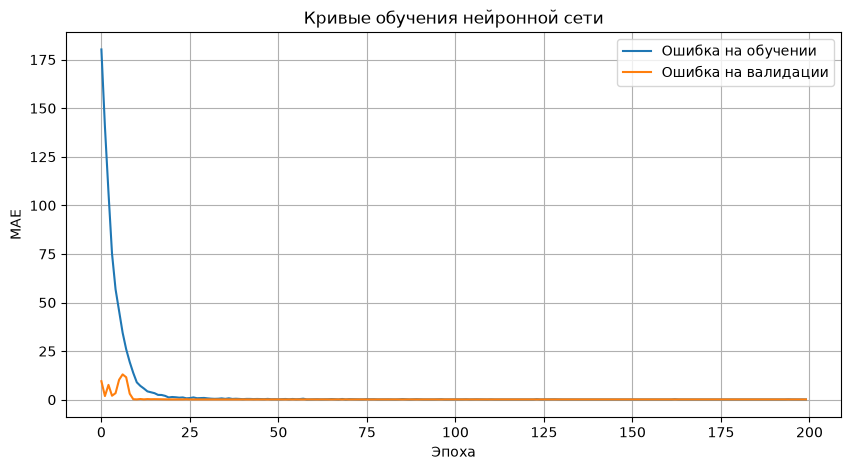

In [31]:
# График обучения
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Ошибка на обучении')
plt.plot(history.history['val_loss'], label='Ошибка на валидации')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.title('Кривые обучения нейронной сети')
plt.show()

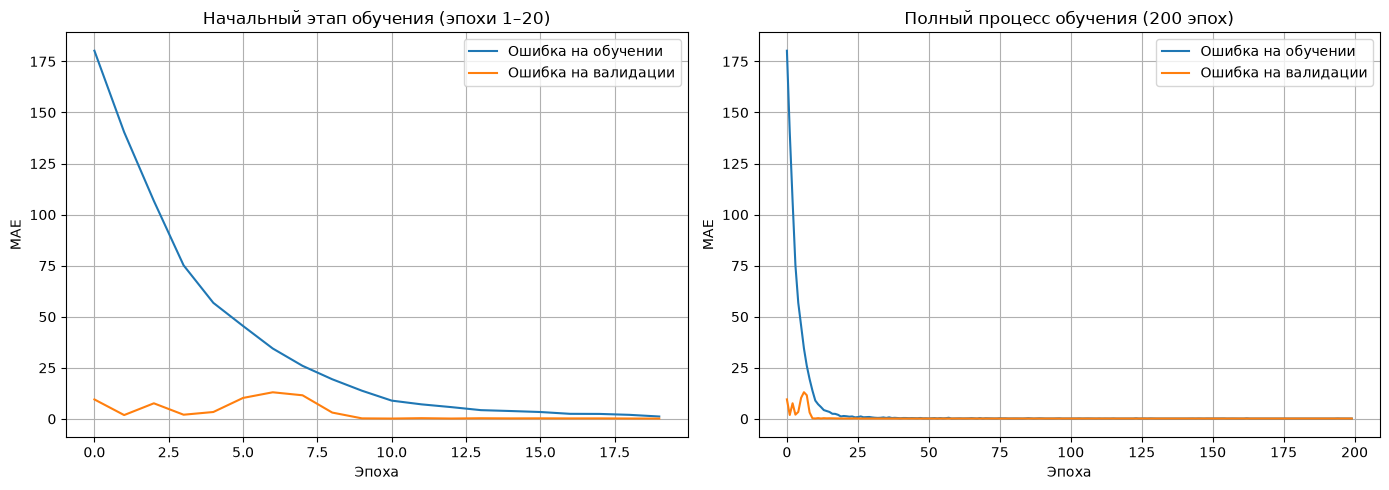

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Левый график: первые 20 эпох (видно падение)
axes[0].plot(history.history['loss'][:20], label='Ошибка на обучении')
axes[0].plot(history.history['val_loss'][:20], label='Ошибка на валидации')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MAE')
axes[0].set_title('Начальный этап обучения (эпохи 1–20)')
axes[0].legend()
axes[0].grid(True)

#Правый график: все 200 эпох
axes[1].plot(history.history['loss'], label='Ошибка на обучении')
axes[1].plot(history.history['val_loss'], label='Ошибка на валидации')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MAE')
axes[1].set_title('Полный процесс обучения (200 эпох)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [33]:
# Оценка на тестовой выборке
y_nn_pred = nn_model.predict(X_nn_test, verbose=0).flatten()

mae = mean_absolute_error(y_nn_test, y_nn_pred)
rmse = np.sqrt(mean_squared_error(y_nn_test, y_nn_pred))
r2 = r2_score(y_nn_test, y_nn_pred)

print("РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ (соотношение матрица-наполнитель)")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ (соотношение матрица-наполнитель)
MAE:  0.1505
RMSE: 0.1867
R²:   -0.0105


In [34]:
print(f"Минимум: {y_nn_test.min():.4f}")
print(f"Максимум: {y_nn_test.max():.4f}")
print(f"Среднее: {y_nn_test.mean():.4f}")
print(f"Стд: {y_nn_test.std():.4f}")

Минимум: 0.0587
Максимум: 0.9884
Среднее: 0.5047
Стд: 0.1861


In [35]:
y_mean = np.full_like(y_nn_test, y_nn_train.mean())
baseline_mae = mean_absolute_error(y_nn_test, y_mean)
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"MAE модели:   {mae:.4f}")
print(f"R² baseline:  0.0000 (по определению)")

Baseline MAE: 0.1496
MAE модели:   0.1505
R² baseline:  0.0000 (по определению)


In [42]:
# Создаём scaler на X_nn (те же 12 признаков, что подаются в нейросеть)
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
scaler.fit(X_nn)
print("Scaler создан на X_nn")
print(f"   Признаков: {scaler.n_features_in_}")

Scaler создан на X_nn
   Признаков: 12


In [41]:
#Сохранение модели и scaler
import joblib

#Сохраняем нейронную сеть
nn_model.save('nn_matrix_filler.keras')
print("Модель сохранена: nn_matrix_filler.keras")

#Сохраняем scaler
joblib.dump(scaler, 'scaler_minmax.pkl')
print("Scaler сохранён: scaler_minmax.pkl")

#Сохраняем порядок признаков 
feature_order = X_nn.columns.tolist()
joblib.dump(feature_order, 'feature_order.pkl')
print("Порядок признаков сохранён:")
for i, col in enumerate(feature_order, 1):
    print(f"   {i}. {col}")

Модель сохранена: nn_matrix_filler.keras
Scaler сохранён: scaler_minmax.pkl
Порядок признаков сохранён:
   1. Плотность, кг/м3
   2. модуль упругости, ГПа
   3. Количество отвердителя, м.%
   4. Содержание эпоксидных групп,%_2
   5. Температура вспышки, С_2
   6. Поверхностная плотность, г/м2
   7. Модуль упругости при растяжении, ГПа
   8. Прочность при растяжении, МПа
   9. Потребление смолы, г/м2
   10. Угол нашивки, град
   11. Шаг нашивки
   12. Плотность нашивки


In [45]:
import os

files = ['nn_matrix_filler.keras', 'scaler_minmax.pkl', 'feature_order.pkl']
for f in files:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    print(f"{'OK' if exists else 'NO'} {f} ({size} байт)")

OK nn_matrix_filler.keras (65297 байт)
OK scaler_minmax.pkl (1943 байт)
OK feature_order.pkl (569 байт)


In [47]:
#Загружаем и проверяем
loaded_scaler = joblib.load('scaler_minmax.pkl')

#Нормализуем одну строку из X_nn
sample = X_nn.iloc[[0]]
scaled = loaded_scaler.transform(sample)

print("Сырые данные:")
print(sample.values)
print("\nНормализованные данные:")
print(scaled)
print("\nВсе значения в [0, 1]:", ((scaled >= 0) & (scaled <= 1)).all())

Сырые данные:
[[6.51097433e-01 4.52950696e-01 7.91527230e-02 6.07435279e-01
  5.09164256e-01 1.62230076e-01 7.00000000e+01 3.00000000e+03
  5.14688097e-01 0.00000000e+00 2.89333985e-01 5.46433021e-01]]

Нормализованные данные:
[[0.65109743 0.4529507  0.07915272 0.60743528 0.50916426 0.16223008
  0.27296208 0.73312678 0.5146881  0.         0.28933398 0.54643302]]

Все значения в [0, 1]: True


In [1]:
import numpy as np
import joblib
from tensorflow import keras
#в этом шаге была дополнительно проверена модель на разных значениях
model = keras.models.load_model('nn_matrix_filler.keras')
scaler = joblib.load('scaler_minmax.pkl')

scaled_indices = [0, 1, 2, 3, 4, 5, 8, 10, 11]

#Тест 1: нормальные значения
f1 = np.array([[1975, 739, 110, 22.2, 285, 482, 73.3, 2466, 220, 0, 5, 57]]).astype(float)
f1[:, scaled_indices] = scaler.transform(f1[:, scaled_indices])
print("Нормальные значения:", model.predict(f1, verbose=0)[0][0])

#Тест 2: все пятёрки
f2 = np.array([[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]]).astype(float)
f2[:, scaled_indices] = scaler.transform(f2[:, scaled_indices])
print("Все пятёрки:        ", model.predict(f2, verbose=0)[0][0])

#Тест 3: все сотни
f3 = np.array([[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100]]).astype(float)
f3[:, scaled_indices] = scaler.transform(f3[:, scaled_indices])
print("Все сотни:          ", model.predict(f3, verbose=0)[0][0])

#Среднее целевой в train
print("\nСреднее y_train:", y_nn_train.mean() if 'y_nn_train' in dir() else 'N/A')

C:\Users\U_M163Z\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Нормальные значения: 0.48569855
Все пятёрки:         0.48569855
Все сотни:           0.48569855

Среднее y_train: N/A


C:\Users\U_M163Z\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\U_M163Z\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
